In [ ]:
# !pip install torch torchvision torchaudio
# !pip install 'git+https://github.com/facebookresearch/detectron2.git'
# !pip install 'git+https://github.com/facebookresearch/detectron2.git@main'

In [1]:
import matplotlib.pyplot as plt

import json
import os
import random
import shutil
from pathlib import Path
from collections import defaultdict

import cv2

import torch

import detectron2
from detectron2.data.datasets import register_coco_instances, load_coco_json
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.engine import DefaultPredictor, DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.evaluation import COCOEvaluator


/Users/jfs-m3/Documents/DS/sum-surfers/.venv/lib/python3.13/site-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [15]:
# # SPLITTING THE DATASET INTO TRAIN/VAL/TEST

# # Output dirs
# output_dir = data_dir / "splits"
# (output_dir / "train").mkdir(parents=True, exist_ok=True)
# (output_dir / "val").mkdir(parents=True, exist_ok=True)
# (output_dir / "test").mkdir(parents=True, exist_ok=True)

# # Load annotations
# with open(ann_file, "r") as f:
#     coco = json.load(f)

# images = coco["images"]
# annotations = coco["annotations"]

# # Count annotations per image
# ann_count = defaultdict(int)
# for ann in annotations:
#     ann_count[ann["image_id"]] += 1

# # Attach annotation counts to each image
# for img in images:
#     img["ann_count"] = ann_count[img["id"]]

# # Shuffle by images (but weighted later)
# random.shuffle(images)

# # Sort images by annotation count (descending) to make splitting more balanced
# images_sorted = sorted(images, key=lambda x: x["ann_count"], reverse=True)

# # Target totals for splits
# total_annotations = sum(ann_count.values())
# train_target = 0.7 * total_annotations
# val_target = 0.2 * total_annotations
# test_target = 0.1 * total_annotations

# splits = {"train": [], "val": [], "test": []}
# split_totals = {"train": 0, "val": 0, "test": 0}

# # Greedy assignment: fill each split until it reaches its target
# for img in images_sorted:
#     # Pick the split that is furthest below target
#     gaps = {
#         k: (target - split_totals[k]) 
#         for k, target in zip(["train", "val", "test"], [train_target, val_target, test_target])
#     }
#     best_split = max(gaps, key=gaps.get)  # largest gap
#     splits[best_split].append(img)
#     split_totals[best_split] += img["ann_count"]

# # Build and save COCO files for each split
# for split_name, split_images in splits.items():
#     split_image_ids = {img["id"] for img in split_images}
#     split_annotations = [ann for ann in annotations if ann["image_id"] in split_image_ids]
    
#     split_coco = {
#         "images": split_images,
#         "annotations": split_annotations,
#         "categories": coco["categories"]
#     }
    
#     with open(output_dir / f"instances_{split_name}.json", "w") as f:
#         json.dump(split_coco, f)
    
#     # Copy images into split folders
#     split_dir = output_dir / split_name
#     for img in split_images:
#         src = images_dir / img["file_name"]
#         dst = split_dir / img["file_name"]
#         shutil.copy(src, dst)

# # Report counts
# print("✅ Dataset split into train/val/test at:", output_dir)
# for split in ["train", "val", "test"]:
#     print(f"{split}: {len(splits[split])} images, {split_totals[split]} annotations")

Project root: /Users/jfs-m3/Documents/DS/sum-surfers
Datasets registered successfully:
['coco_2014_train', 'coco_2014_val', 'coco_2014_minival', 'coco_2014_valminusminival', 'coco_2017_train', 'coco_2017_val', 'coco_2017_test', 'coco_2017_test-dev', 'coco_2017_val_100', 'keypoints_coco_2014_train', 'keypoints_coco_2014_val', 'keypoints_coco_2014_minival', 'keypoints_coco_2014_valminusminival', 'keypoints_coco_2017_train', 'keypoints_coco_2017_val', 'keypoints_coco_2017_val_100', 'coco_2017_train_panoptic_separated', 'coco_2017_train_panoptic_stuffonly', 'coco_2017_train_panoptic', 'coco_2017_val_panoptic_separated', 'coco_2017_val_panoptic_stuffonly', 'coco_2017_val_panoptic', 'coco_2017_val_100_panoptic_separated', 'coco_2017_val_100_panoptic_stuffonly', 'coco_2017_val_100_panoptic', 'lvis_v1_train', 'lvis_v1_val', 'lvis_v1_test_dev', 'lvis_v1_test_challenge', 'lvis_v0.5_train', 'lvis_v0.5_val', 'lvis_v0.5_val_rand_100', 'lvis_v0.5_test', 'lvis_v0.5_train_cocofied', 'lvis_v0.5_val_coc

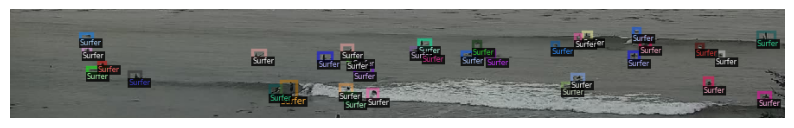

In [18]:
# # REGISTERING THE DATASETS IN DETECTRON2 & SETTING FOLDER PATHS
# --- Project structure ---
project_root = Path.cwd().parent
print("Project root:", project_root)

data_dir = project_root / "data" / "cvat_out_coco"
images_dir = data_dir / "images" / "default"
ann_file = data_dir / "annotations" / "instances_default.json"
splits_dir = project_root / "data" / "cvat_out_coco" / "splits"

# --- Annotation paths ---
train_json = splits_dir / "instances_train.json"
val_json = splits_dir / "instances_val.json"
test_json = splits_dir / "instances_test.json"

# --- Image dirs ---
train_img_dir = splits_dir / "train"
val_img_dir = splits_dir / "val"
test_img_dir = splits_dir / "test"

# --- Dataset names ---
train_name = "surfers_train"
val_name = "surfers_val"
test_name = "surfers_test"

# --- Unregister if already registered ---
for d in [train_name, val_name, test_name]:
    if d in DatasetCatalog.list():
        DatasetCatalog.remove(d)
        MetadataCatalog.remove(d)

# --- Register datasets ---
register_coco_instances(train_name, {}, str(train_json), str(train_img_dir))
register_coco_instances(val_name, {}, str(val_json), str(val_img_dir))
register_coco_instances(test_name, {}, str(test_json), str(test_img_dir))

print("Datasets registered successfully:")
print(DatasetCatalog.list())

# --- Visualization helper ---
def visualize_random_samples(dataset_name, img_dir, n=3):
    dataset_dicts = DatasetCatalog.get(dataset_name)
    metadata = MetadataCatalog.get(dataset_name)
    
    for d in random.sample(dataset_dicts, n):
        # Rebuild full path (in case COCO JSON has only filenames or wrong prefix)
        img_path = os.path.join(img_dir, os.path.basename(d["file_name"]))
        img = cv2.imread(img_path)

        if img is None:
            print(f"⚠️ Could not read image: {img_path}")
            continue

        visualizer = Visualizer(
            img[:, :, ::-1],
            metadata=metadata,
            scale=0.7,
            instance_mode=ColorMode.IMAGE_BW
        )
        vis = visualizer.draw_dataset_dict(d)

        plt.figure(figsize=(10, 7))
        plt.imshow(vis.get_image()[:, :, ::-1])
        plt.axis("off")
        plt.show()

# --- Try it out on training set ---
visualize_random_samples(train_name, str(train_img_dir), n=1)

In [19]:
# Trying to use MPS on Mac instead of CPU
import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(device)  # should print "mps"

mps


In [ ]:
# # VISUALIZING PREDICTIONS

# # --- One-time setup of predictor and dataset ---
# if "predictor" not in globals():
#     print("🔧 Setting up predictor and dataset...")

#     cfg = get_cfg()
#     cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

#     cfg.DATASETS.TRAIN = ("surfers_train",)
#     cfg.DATASETS.TEST = ("surfers_val",)
#     cfg.DATALOADER.NUM_WORKERS = 2

#     cfg.MODEL.WEIGHTS = "models_test/model_final.pth"
#     cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.1
#     cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1
#     cfg.MODEL.DEVICE = "mps"   # Apple GPU

#     predictor = DefaultPredictor(cfg)

#     dataset_dicts = DatasetCatalog.get("surfers_val")  # or "surfers_test"
#     metadata = MetadataCatalog.get("surfers_val")

# # --- Ensure global counter exists ---
# if "img_index" not in globals():
#     img_index = 0

# # --- Always runs: pick next image ---
# d = dataset_dicts[img_index % len(dataset_dicts)]
# img_index += 1  # increment

# img = cv2.imread(d["file_name"])
# outputs = predictor(img)

# v = Visualizer(img[:, :, ::-1], metadata=metadata, scale=1.2)
# out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# plt.figure(figsize=(12, 6))
# plt.imshow(out.get_image())
# plt.axis("off")
# plt.show()

# print(f"✅ Showing image {img_index}/{len(dataset_dicts)}: {d['file_name']}")

In [ ]:
# # CHECKING THE NUMBER OF CLASSES IN THE MODEL
# import torch
# state_dict = torch.load("models/model_final.pth")
# print([k for k in state_dict.keys() if "roi_heads.box_predictor" in k])

In [ ]:
# # MODEL TRAINING V2 - WITH CUSTOM TRAINER AND COCO EVALUATOR FOR mAPS
# # --- Paths ---
# project_root = Path.cwd()
# output_dir = project_root / "models_test"
# output_dir.mkdir(exist_ok=True, parents=True)

# # --- Device selection ---
# device = "cuda" if torch.cuda.is_available() else (
#     "mps" if torch.backends.mps.is_available() else "cpu"
# )
# print(f"Using device: {device}")

# # --- Custom Trainer with COCO evaluator ---
# class MyTrainer(DefaultTrainer):
#     @classmethod
#     def build_evaluator(cls, cfg, dataset_name, output_folder=None):
#         if output_folder is None:
#             output_folder = os.path.join(cfg.OUTPUT_DIR, "eval")
#         return COCOEvaluator(dataset_name, cfg, False, output_folder)

# # --- Config ---
# cfg = get_cfg()
# cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

# # Datasets
# cfg.DATASETS.TRAIN = ("surfers_train",)
# cfg.DATASETS.TEST = ("surfers_val",)

# # Dataloader
# cfg.DATALOADER.NUM_WORKERS = 2
# cfg.SOLVER.IMS_PER_BATCH = 2

# # Solver (learning rate & schedule)
# cfg.SOLVER.BASE_LR = 0.00025
# cfg.SOLVER.MAX_ITER = 2000        # 🔹 smoke test only
# cfg.SOLVER.CHECKPOINT_PERIOD = 500  # save model every 500 iters

# # ROI heads
# cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256
# cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # 1 class: surfer

# # Model weights
# cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
#     "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
# )

# # Device + output
# cfg.MODEL.DEVICE = device
# cfg.OUTPUT_DIR = str(output_dir)

# # --- Train ---
# os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
# trainer = MyTrainer(cfg)
# trainer.resume_or_load(resume=False)
# trainer.train()

In [ ]:
# TRAINING TO OVERFIT ON 2 IMAGES
import torch
from pathlib import Path
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.data import MetadataCatalog, DatasetCatalog

# Remove old registration if it exists
if "surfers_train_overfit" in DatasetCatalog.list():
    DatasetCatalog.remove("surfers_train_overfit")
    MetadataCatalog.remove("surfers_train_overfit")

# --- Dataset subset (first 2 images only) ---
all_dicts = DatasetCatalog.get("surfers_train")
DatasetCatalog.register("surfers_train_overfit", lambda: all_dicts[:2])
MetadataCatalog.get("surfers_train_overfit").set(thing_classes=["Surfer"])

# --- Config ---
cfg_overfit = get_cfg()
cfg_overfit.merge_from_file(
    model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
)

cfg_overfit.DATASETS.TRAIN = ("surfers_train_overfit",)
cfg_overfit.DATASETS.TEST = ()  # no test
cfg_overfit.DATALOADER.NUM_WORKERS = 0

# Anchors (smaller for surfers)
cfg_overfit.MODEL.ANCHOR_GENERATOR.SIZES = [[16, 32, 64, 128]]
cfg_overfit.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [[0.5, 1.0, 2.0]]

# Solver
cfg_overfit.SOLVER.IMS_PER_BATCH = 2
cfg_overfit.SOLVER.BASE_LR = 0.001
cfg_overfit.SOLVER.MAX_ITER = 200
cfg_overfit.SOLVER.CHECKPOINT_PERIOD = 100
cfg_overfit.SOLVER.STEPS = []  # avoid warnings

# ROI heads
cfg_overfit.MODEL.ROI_HEADS.NUM_CLASSES = 1
cfg_overfit.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.1
cfg_overfit.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256

# No pretrained weights → force fresh heads
cfg_overfit.MODEL.WEIGHTS = ""

# Device
cfg_overfit.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu"
)

# Output dir
output_dir = Path("models_overfit")
cfg_overfit.OUTPUT_DIR = str(output_dir)
output_dir.mkdir(exist_ok=True, parents=True)

# --- Train ---
trainer = DefaultTrainer(cfg_overfit)
trainer.resume_or_load(resume=False)
trainer.train()

[10/01 08:11:22 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

/Users/jfs-m3/Documents/DS/sum-surfers/.venv/lib/python3.13/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[10/01 06:32:08 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from  ...


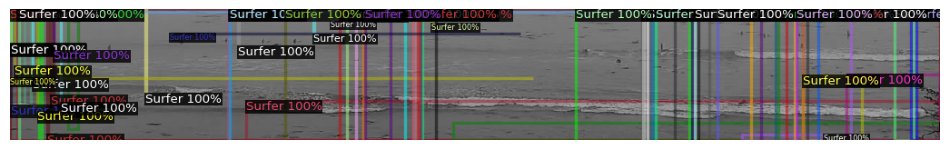

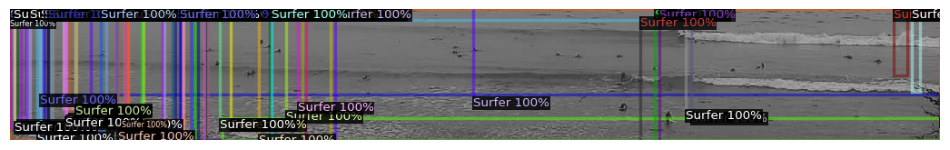

In [25]:
## VISUALIZE OVERFITTING RESULTS
predictor = DefaultPredictor(cfg_overfit)

import random
from detectron2.utils.visualizer import ColorMode

dataset_dicts = DatasetCatalog.get("surfers_train_overfit")

for d in dataset_dicts:
    img = cv2.imread(d["file_name"])
    outputs = predictor(img)

    v = Visualizer(
        img[:, :, ::-1],
        metadata=MetadataCatalog.get("surfers_train_overfit"),
        scale=0.8,
        instance_mode=ColorMode.IMAGE_BW
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    plt.figure(figsize=(12, 8))
    plt.imshow(out.get_image())
    plt.axis("off")
    plt.show()